# Wavemaker numerical notebook

This notebook presents a compact numerical check of the wavemaker model used in the thesis.

You can run it from any folder. The configuration cell below defines CODE_DIR so the working location is easy to change if needed.

In [1]:
# Cell 1: imports and basic configuration
# Change CODE_DIR if you want to run the notebook from another directory.
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

CODE_DIR = Path.cwd().resolve()
# Example: CODE_DIR = Path(r"C:/path/to/your/notebook/folder")

print(f"Notebook directory: {CODE_DIR}")

h = 0.300 m
S = 0.025 m
b = 0.0125 m = 12.5 mm
k0b will be calculated as k0 * b


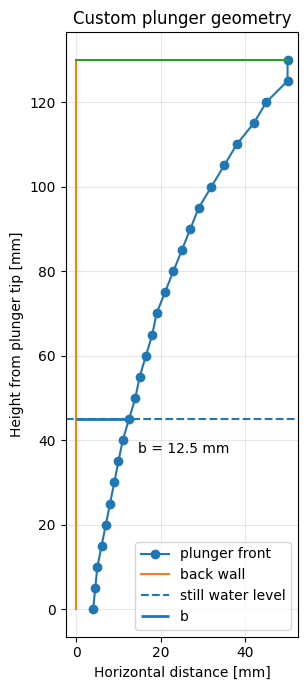

In [5]:
# Cell 2: geometrical model
# All lengths are given in metres unless the variable name says otherwise.

# Constants and tank/wavemaker dimensions
g = 9.81                       # gravitational acceleration [m/s^2]
h = 0.30                       # water depth [m]
S = 0.025                      # plunger stroke amplitude [m]
d_sub = 0.045                  # submerged plunger depth from tip to still water level [m]
plunger_height = 0.130         # total plunger height [m]
top_width = 0.050              # plunger width at the top [m]

# Plunger front shape.
# Values are the horizontal distance from the back wall to the plunger front.
# The list starts at the top of the plunger and ends at the tip.
x_from_back_top_to_tip_cm = np.array([
    5.0, 5.0, 4.5, 4.2, 3.8, 3.5, 3.2, 2.9, 2.7,
    2.5, 2.3, 2.1, 1.9, 1.8, 1.65, 1.5, 1.4, 1.25,
    1.1, 1.0, 0.9, 0.8, 0.7, 0.60, 0.5, 0.45, 0.4,
], dtype=float)

# Use z as height measured upward from the plunger tip.
z_profile = np.arange(0.0, plunger_height + 0.005, 0.005)       # [m]
x_profile = x_from_back_top_to_tip_cm[::-1] / 100.0             # [m]

# Effective plunger width at the still water level.
b = float(np.interp(d_sub, z_profile, x_profile))               # [m]

print(f"h = {h:.3f} m")
print(f"S = {S:.3f} m")
print(f"b = {b:.4f} m = {1000*b:.1f} mm")
print(f"k0b will be calculated as k0 * b")

# Plot the two-dimensional plunger geometry.
fig, ax = plt.subplots(figsize=(5.0, 7.0))
ax.plot(1000 * x_profile, 1000 * z_profile, marker="o", label="plunger front")
ax.plot([0, 0], [0, 1000 * plunger_height], label="back wall")
ax.plot([0, 1000 * top_width], [1000 * plunger_height, 1000 * plunger_height])
ax.axhline(1000 * d_sub, linestyle="--", label="still water level")
ax.hlines(1000 * d_sub -0 , 0, 1000 * b, linewidth=2, label="b")
ax.text(1000 * b + 2, 1000 * d_sub - 8, f"b = {1000*b:.1f} mm")
ax.set_aspect("equal")
ax.set_xlabel("Horizontal distance [mm]")
ax.set_ylabel("Height from plunger tip [mm]")
ax.set_title("Custom plunger geometry")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

,wave_case,f_eta [Hz],omega [rad/s],k0 [1/m],k0b [-],a/S [-],a_measured [cm],a_theoretical [cm],error [%],C [-]
0,W60,1.9860,12.4784,15.8750,0.1984,0.1995,0.634,0.499,-21.3,1.271
1,W66,2.1364,13.4234,18.3683,0.2296,0.2212,0.716,0.553,-22.8,1.295
2,W70,2.2550,14.1686,20.4639,0.2558,0.2380,0.789,0.595,-24.6,1.326
3,W76,2.4750,15.5509,24.6514,0.3081,0.2682,0.802,0.671,-16.4,1.196
4,W80,2.5240,15.8588,25.6371,0.3205,0.2748,0.903,0.687,-23.9,1.314


Mean amplitude error [%] = -21.8
Mean C [-] = 1.28


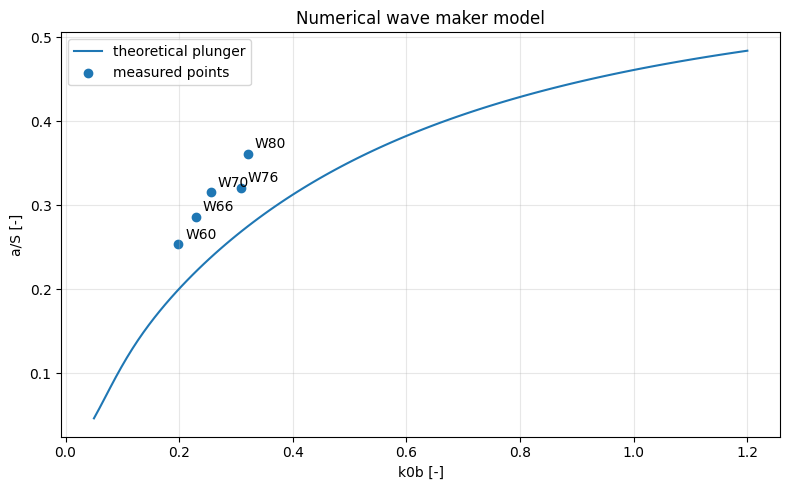

In [3]:
# Cell 3: numerical model
# This cell calculates k0, a/S, a_theoretical, error, and C.

# Measured wave data used in the comparison.
# a_measured is the measured wave amplitude.
# f_eta is the measured wave frequency used as input to the model.
wave_case = np.array(["W60", "W66", "W70", "W76", "W80"])
a_measured = np.array([0.634, 0.716, 0.789, 0.802, 0.903]) / 100.0   # [m]

# Frequencies used for the numerical comparison.
# W66 uses the frequency from the selected 6--10 s comparison window in the original notebook.
f_eta = np.array([1.986, 2.1364, 2.255, 2.475, 2.524])              # [Hz]
omega = 2.0 * np.pi * f_eta                                        # [rad/s]


def bisection_root(function, left, right, tolerance=1e-12, max_iter=200):
    """Small bisection solver used to avoid extra dependencies."""
    f_left = function(left)
    f_right = function(right)

    if f_left * f_right > 0:
        raise ValueError("The root is not bracketed.")

    for _ in range(max_iter):
        mid = 0.5 * (left + right)
        f_mid = function(mid)

        if abs(f_mid) < tolerance or abs(right - left) < tolerance:
            return mid

        if f_left * f_mid <= 0:
            right = mid
            f_right = f_mid
        else:
            left = mid
            f_left = f_mid

    return 0.5 * (left + right)


def calculate_k0(omega_value, h, g=9.81):
    """Calculate k0 from omega^2 = g*k0*tanh(k0*h)."""
    def dispersion_error(k0):
        return g * k0 * np.tanh(k0 * h) - omega_value**2

    left = 1e-12
    right = max(1.0, 2.0 * omega_value**2 / g + 10.0 / h)

    while dispersion_error(right) < 0:
        right *= 2.0

    return bisection_root(dispersion_error, left, right)


def calculate_kn(k0, h, N):
    """Calculate the evanescent wave numbers kn."""
    V = k0 * h * np.tanh(k0 * h)
    kn = []

    for n in range(1, N + 1):
        left = (n - 0.5) * np.pi + 1e-10
        right = n * np.pi - 1e-10
        mu_n = bisection_root(lambda mu: mu * np.tan(mu) + V, left, right)
        kn.append(mu_n / h)

    return np.array(kn)


def solve_plunger_model(k0, h, z_profile, x_profile, d_sub, M=250, N=15):
    """
    Boundary-collocation solution for the plunger model.

    Returns:
        a_over_S : wave-amplitude-to-stroke ratio [-]
        A0       : progressive-wave coefficient
        An       : evanescent-mode coefficients
        kn       : evanescent wave numbers [1/m]
    """
    kn = calculate_kn(k0, h, N)

    # Collocation points from tank bottom to still water level.
    y = np.linspace(0.0, h, M)

    # The plunger tip is d_sub below the still water level.
    y_tip = h - d_sub
    z_local = y - y_tip

    # Geometry along the wetted plunger surface.
    x = np.zeros_like(y)
    dx_dz = np.zeros_like(y)
    wetted = y >= y_tip

    slope_profile = np.gradient(x_profile, z_profile)
    x[wetted] = np.interp(z_local[wetted], z_profile, x_profile)
    dx_dz[wetted] = np.interp(z_local[wetted], z_profile, slope_profile)

    # Right-hand side from the plunger boundary condition.
    D = dx_dz.reshape(-1, 1).astype(complex)

    # First column: progressive wave with coefficient A0.
    B0 = (k0 * h) * (
        1j * np.cosh(k0 * y) - dx_dz * np.sinh(k0 * y)
    ) * np.exp(1j * k0 * x)
    B = B0.reshape(-1, 1)

    # Remaining columns: evanescent modes with coefficients An.
    for kn_value in kn:
        Bn = -(kn_value * h) * (
            np.cos(kn_value * y) - dx_dz * np.sin(kn_value * y)
        ) * np.exp(-kn_value * x)
        B = np.hstack([B, Bn.reshape(-1, 1)])

    A, *_ = np.linalg.lstsq(B, D, rcond=None)
    A0 = A[0, 0]
    An = A[1:, 0]

    a_over_S = abs(A0 * k0 * h * np.sinh(k0 * h))

    return float(a_over_S), A0, An, kn


# Calculate numerical result for each wave case.
rows = []
A0_by_case = {}
An_by_case = {}
kn_by_case = {}

for label, f_value, omega_value, a_value in zip(wave_case, f_eta, omega, a_measured):
    k0 = calculate_k0(omega_value, h, g)
    k0b = k0 * b
    a_over_S, A0, An, kn = solve_plunger_model(k0, h, z_profile, x_profile, d_sub)

    a_theoretical = S * a_over_S
    error_percent = 100.0 * (a_theoretical - a_value) / a_value
    C = a_value / a_theoretical

    A0_by_case[label] = A0
    An_by_case[label] = An
    kn_by_case[label] = kn

    rows.append({
        "wave_case": label,
        "f_eta [Hz]": f_value,
        "omega [rad/s]": omega_value,
        "k0 [1/m]": k0,
        "k0b [-]": k0b,
        "a/S [-]": a_over_S,
        "a_measured [cm]": 100.0 * a_value,
        "a_theoretical [cm]": 100.0 * a_theoretical,
        "error [%]": error_percent,
        "C [-]": C,
    })

results = pd.DataFrame(rows)
display(results.round({
    "f_eta [Hz]": 4,
    "omega [rad/s]": 4,
    "k0 [1/m]": 4,
    "k0b [-]": 4,
    "a/S [-]": 4,
    "a_measured [cm]": 3,
    "a_theoretical [cm]": 3,
    "error [%]": 1,
    "C [-]": 3,
}))

print("Mean amplitude error [%] =", round(float(results["error [%]"].mean()), 1))
print("Mean C [-] =", round(float(results["C [-]"].mean()), 3))

# Theoretical curve and measured points.
k0b_curve = np.linspace(0.05, 1.20, 120)
a_over_S_curve = []

for k0b_value in k0b_curve:
    k0_value = k0b_value / b
    a_over_S_value, _, _, _ = solve_plunger_model(k0_value, h, z_profile, x_profile, d_sub)
    a_over_S_curve.append(a_over_S_value)

a_over_S_curve = np.array(a_over_S_curve)

fig, ax = plt.subplots(figsize=(8.0, 5.0))
ax.plot(k0b_curve, a_over_S_curve, label="theoretical plunger")
ax.scatter(results["k0b [-]"], results["a_measured [cm]"] / (100.0 * S), label="measured points")

for _, row in results.iterrows():
    ax.annotate(row["wave_case"], (row["k0b [-]"], row["a_measured [cm]"] / (100.0 * S)), xytext=(5, 4), textcoords="offset points")

ax.set_xlabel("k0b [-]")
ax.set_ylabel("a/S [-]")
ax.set_title("Numerical wave maker model")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()